# Exploratory Data Analysis (EDA)
## GNN-Based BERT for Understanding Context from Music
**Course:** Neural Networks (CSE425 / EEE474 / CSE715)

---

### Notebook Overview
This notebook explores the two primary datasets powering our multimodal music context system:
1. **GTZAN Dataset**: 1,000 30-second audio tracks across 10 distinct musical genres.
2. **MusicCaps Dataset**: 5,521 10-second music clips accompanied by rich expert human textual captions and aspect lists.

We analyze:
- Audio feature representations (Waveforms, Mel-Spectrograms, MFCCs, Chromagrams)
- Musical structure graphs (Segment temporal & similarity graphs)
- Textual aspect and caption distributions in MusicCaps


In [1]:
import os
import sys
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import torch
import networkx as nx
from pathlib import Path

# Robust project_root detection
for candidate in [Path("."), Path(".."), Path("e:/cse_425_project")]:
    if (candidate / "config.yaml").exists():
        project_root = candidate.resolve()
        break
else:
    project_root = Path("e:/cse_425_project").resolve()

sys.path.insert(0, str(project_root / "src"))

import audio_features
import graph_builder

# Set aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print(f"✅ Environment configured successfully! Project root: {project_root}")


✅ Environment configured successfully! Project root: E:\cse_425_project


---
## 1. GTZAN Genre Classification Dataset

The GTZAN dataset comprises 100 audio tracks per genre across 10 genres:
`['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']`.


In [2]:
with open(project_root / "config.yaml") as f:
    config = yaml.safe_load(f)

genre_labels = config["genre_labels"]
print(f"Total genres: {len(genre_labels)}")
print("Genres:", genre_labels)

# Verify processed graphs and mel-specs
gtzan_graphs_dir = project_root / config["paths"]["processed_gtzan_graphs"]
mel_specs_dir = project_root / config["paths"]["mel_specs"]

num_graphs = len(list(gtzan_graphs_dir.glob("*.pt")))
num_mels = len(list(mel_specs_dir.glob("*.npy")))
print(f"Preprocessed PyG Graphs: {num_graphs} / 1000")
print(f"Preprocessed Mel-Spectrograms: {num_mels} / 1000")


Total genres: 10
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Preprocessed PyG Graphs: 999 / 1000
Preprocessed Mel-Spectrograms: 999 / 1000


### 1.1 Audio Feature Representation: Waveforms & Mel-Spectrograms
Comparing contrasting genres (e.g. Classical vs Metal vs Hiphop vs Jazz):


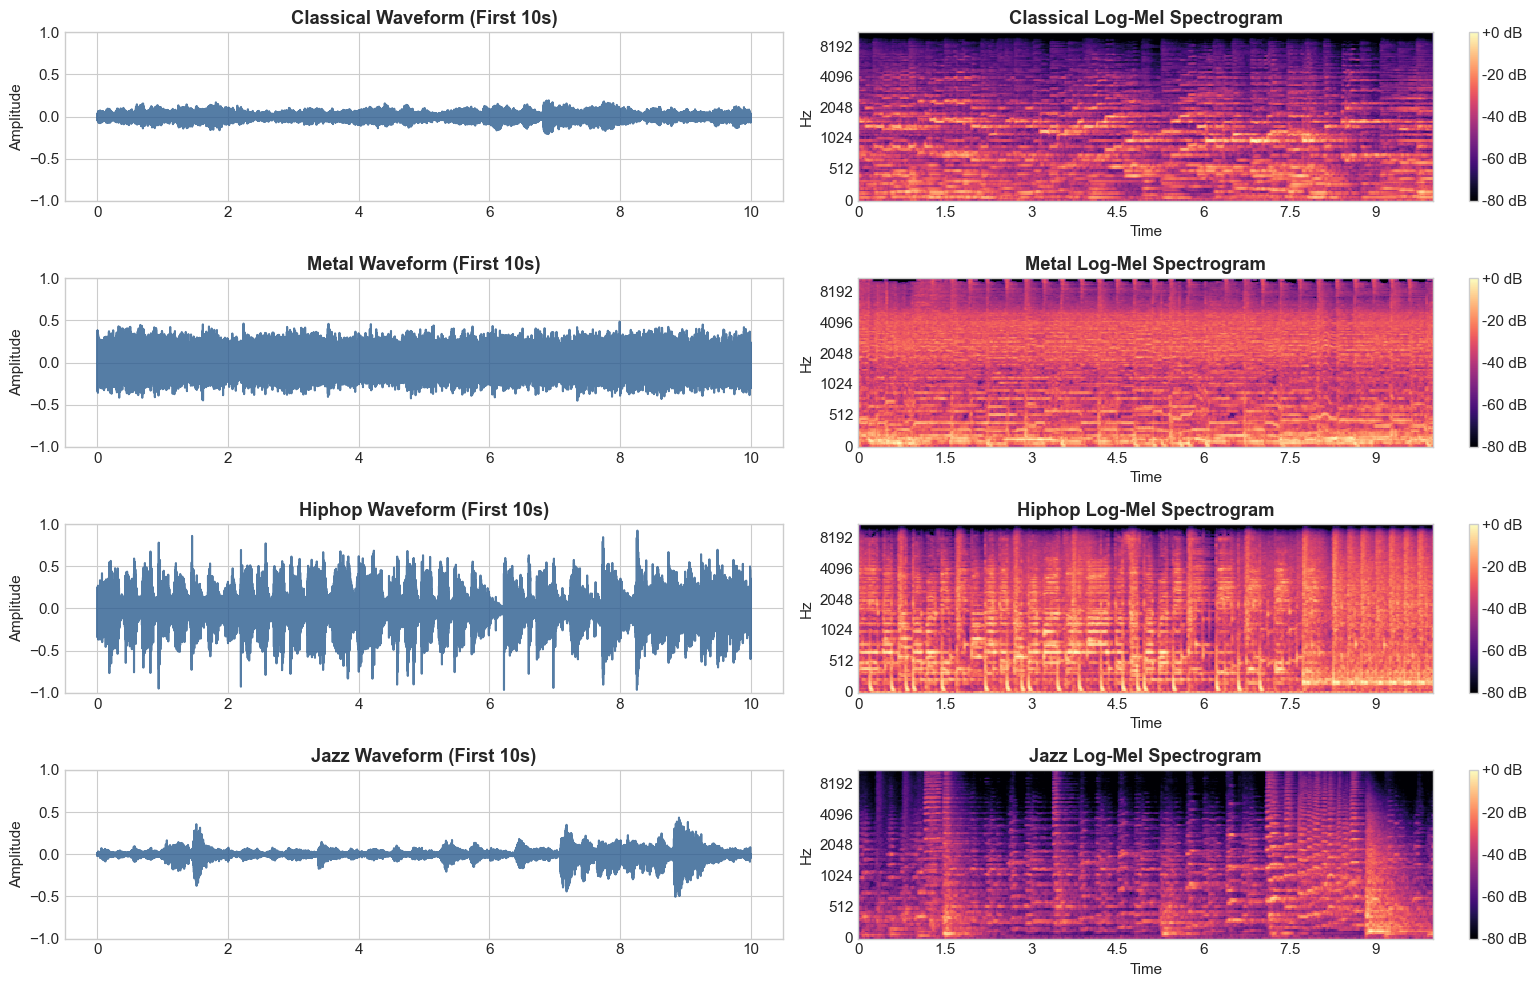

In [3]:
sample_genres = ["classical", "metal", "hiphop", "jazz"]
fig, axes = plt.subplots(len(sample_genres), 2, figsize=(16, 10))

for idx, genre in enumerate(sample_genres):
    # Load audio file
    audio_file = project_root / config["paths"]["gtzan_audio"] / genre / f"{genre}.00000.wav"
    if not audio_file.exists():
        audio_file = project_root / "archive (2)" / "Data" / "genres_original" / genre / f"{genre}.00000.wav"
    
    if audio_file.exists():
        y, sr = librosa.load(str(audio_file), sr=22050, duration=10.0)
        
        # Waveform
        axes[idx, 0].plot(np.linspace(0, 10, len(y)), y, color="#2b5c8f", alpha=0.8)
        axes[idx, 0].set_title(f"{genre.capitalize()} Waveform (First 10s)", fontweight="bold")
        axes[idx, 0].set_ylabel("Amplitude")
        axes[idx, 0].set_ylim(-1, 1)
        
        # Mel Spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sr, ax=axes[idx, 1], cmap="magma")
        axes[idx, 1].set_title(f"{genre.capitalize()} Log-Mel Spectrogram", fontweight="bold")
        fig.colorbar(img, ax=axes[idx, 1], format="%+2.0f dB")

plt.tight_layout()
plt.show()


### 1.2 Music Structure Graph Construction
Each audio track is segmented into fixed-duration chunks (5 seconds).
- **Nodes**: Audio segments with feature embeddings (concatenated Log-Mel mean, Chroma mean, and MFCC mean $\to$ 160 dimensions).
- **Edges**: 
  1. Temporal adjacency edges (consecutive segments are sequentially linked).
  2. Acoustic similarity edges (segments with cosine similarity $> \tau = 0.85$ are linked).


Graph Track ID: blues.00000
Number of segment nodes: 6
Node feature dimension: 160
Number of edges: 36


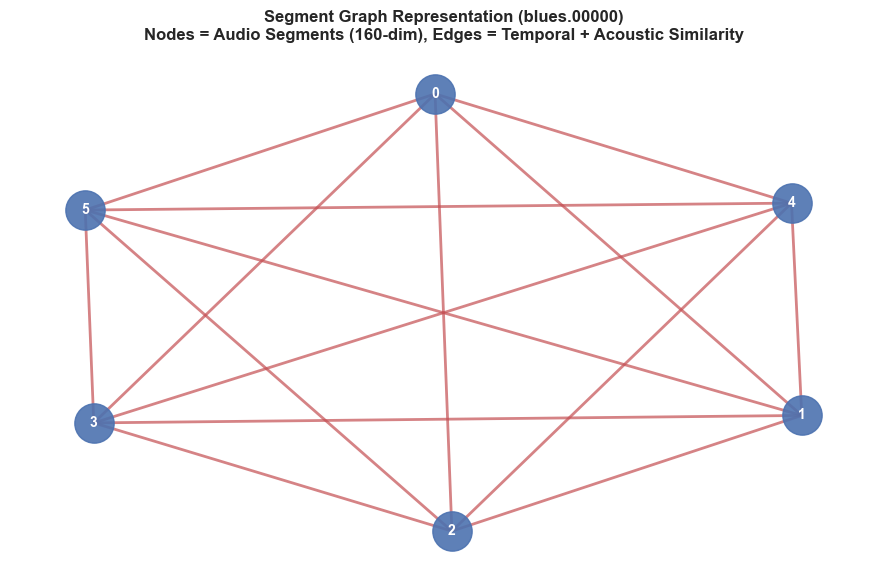

In [4]:
sample_graph_file = list(gtzan_graphs_dir.glob("*.pt"))[0]
graph_data = torch.load(sample_graph_file, weights_only=False)

print(f"Graph Track ID: {sample_graph_file.stem}")
print(f"Number of segment nodes: {graph_data.x.shape[0]}")
print(f"Node feature dimension: {graph_data.x.shape[1]}")
print(f"Number of edges: {graph_data.edge_index.shape[1]}")

# Convert PyG graph to NetworkX for visualization
G = nx.Graph()
for i in range(graph_data.x.shape[0]):
    G.add_node(i, label=f"Seg {i+1}")

edge_index = graph_data.edge_index.numpy()
for src, dst in zip(edge_index[0], edge_index[1]):
    if src < dst:
        G.add_edge(src, dst)

plt.figure(figsize=(9, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_color="#4C72B0", node_size=800, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color="#C44E52", width=2, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold", font_size=10)

plt.title(f"Segment Graph Representation ({sample_graph_file.stem})\nNodes = Audio Segments (160-dim), Edges = Temporal + Acoustic Similarity", fontsize=12, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()


---
## 2. MusicCaps Dataset Exploratory Analysis

MusicCaps provides 5,521 pairs of 10-second audio clips with high-quality free-text captions written by professional musicians and researchers.


In [5]:
musiccaps_meta_path = project_root / config["paths"]["musiccaps_metadata"]
df_caps = pd.read_csv(musiccaps_meta_path)
print(f"Total MusicCaps entries: {len(df_caps)}")
df_caps.head(3)


Total MusicCaps entries: 5521


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True


### 2.1 Aspect Tag Vocabulary & Frequency
Extracting and visualizing the most frequent aspect tags from the dataset:


Active Tag Vocabulary (50 tags):
['low quality', 'instrumental', 'emotional', 'noisy', 'passionate', 'medium tempo', 'energetic', 'amateur recording', 'live performance', 'slow tempo', 'acoustic drums', 'fast tempo', 'mono', 'groovy', 'bass guitar'] ...


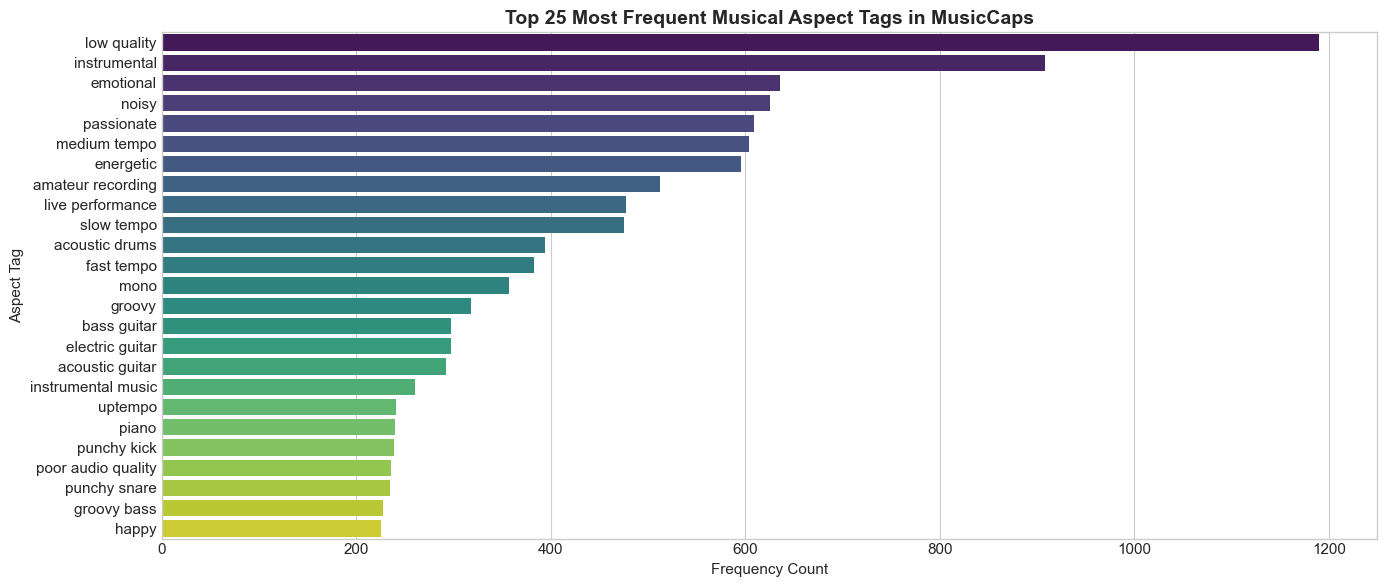

In [6]:
from collections import Counter
from dataset import extract_tags_from_aspects

vocab_path = project_root / config["paths"]["splits"] / "tag_vocabulary.json"
if vocab_path.exists():
    with open(vocab_path) as f:
        tag_vocab = json.load(f)
    print(f"Active Tag Vocabulary ({len(tag_vocab)} tags):")
    print(tag_vocab[:15], "...")

all_tags = []
for aspects in df_caps["aspect_list"].dropna():
    all_tags.extend(extract_tags_from_aspects(aspects))

tag_counts = Counter(all_tags).most_common(25)
tags, counts = zip(*tag_counts)

plt.figure(figsize=(14, 6))
sns.barplot(x=list(counts), y=list(tags), palette="viridis")
plt.title("Top 25 Most Frequent Musical Aspect Tags in MusicCaps", fontsize=14, fontweight="bold")
plt.xlabel("Frequency Count")
plt.ylabel("Aspect Tag")
plt.tight_layout()
plt.show()


### 2.2 Caption Length Distribution
Understanding the linguistic context and token budget for BERT encoder:


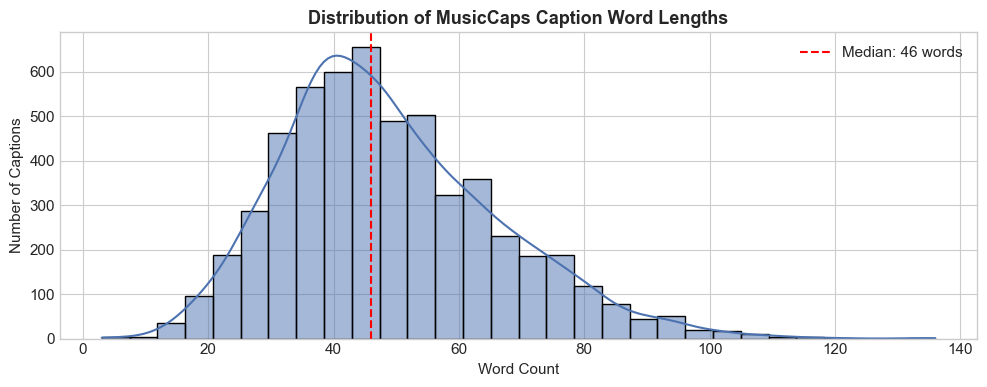

In [7]:
caption_lengths = df_caps["caption"].dropna().apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
sns.histplot(caption_lengths, bins=30, kde=True, color="#4C72B0")
plt.axvline(caption_lengths.median(), color="red", linestyle="--", label=f"Median: {caption_lengths.median():.0f} words")
plt.title("Distribution of MusicCaps Caption Word Lengths", fontsize=13, fontweight="bold")
plt.xlabel("Word Count")
plt.ylabel("Number of Captions")
plt.legend()
plt.tight_layout()
plt.show()


### 2.3 Sample Contextual Captions
Let's inspect sample descriptions to see the depth of musical context captured:


In [8]:
for idx, row in df_caps.head(3).iterrows():
    print(f"\n{'='*70}")
    print(f"Track ID: {row['ytid']} | Time: {row['start_s']}s - {row['end_s']}s")
    print(f"Aspect List: {row['aspect_list']}")
    print(f"Caption: {row['caption']}")



Track ID: -0Gj8-vB1q4 | Time: 30s - 40s
Aspect List: ['low quality', 'sustained strings melody', 'soft female vocal', 'mellow piano melody', 'sad', 'soulful', 'ballad']
Caption: The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.

Track ID: -0SdAVK79lg | Time: 30s - 40s
Aspect List: ['guitar song', 'piano backing', 'simple percussion', 'relaxing melody', 'slow tempo', 'bass', 'country feel', 'instrumental', 'no voice']
Caption: This song features an electric guitar as the main instrument. The guitar plays a descending run in the beginning then plays an arpeggiated chord followed by a double stop hammer on to a higher note and a descending slide followed by a descending chord run. The percussion plays a simple beat using rim shots. The percussion plays in common time. The bass plays only one note on the first count of each